In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# **Part 1: Dataset Acquisition**


In [6]:
import kagglehub

# Pull the Brain Tumour MRI dataset using the Kaggle API
dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

# Build absolute paths to the training and testing splits
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

print("Dataset Path:", dataset_path)


Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset Path: /kaggle/input/brain-tumor-mri-dataset


# **Part 2: Exploratory Data Analysis**


### 2.1. Class Labels


In [7]:
# Subfolder names correspond to tumour class labels
classes = os.listdir(train_path)

print("Classes:", classes)
print("Number of Classes:", len(classes))


Classes: ['pituitary', 'notumor', 'meningioma', 'glioma']
Number of Classes: 4


### 2.2. Images per Class


In [8]:
info = []

# Tally the number of images in every class directory
for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    info.append([cls, count])

dataframe = pd.DataFrame(info, columns=["Class", "Image Count"])
print(dataframe)


        Class  Image Count
0   pituitary         1400
1     notumor         1400
2  meningioma         1400
3      glioma         1400


### 2.3. Summary Statistics


In [9]:
# Display aggregate and per-class image counts
print("Total Images:", dataframe["Image Count"].sum())
print("Average:", dataframe["Image Count"].mean())
print("Max Class:", dataframe.loc[dataframe["Image Count"].idxmax()])
print("Min Class:", dataframe.loc[dataframe["Image Count"].idxmin()])


Total Images: 5600
Average: 1400.0
Max Class: Class          pituitary
Image Count         1400
Name: 0, dtype: object
Min Class: Class          pituitary
Image Count         1400
Name: 0, dtype: object


### 2.4. Class Distribution Chart


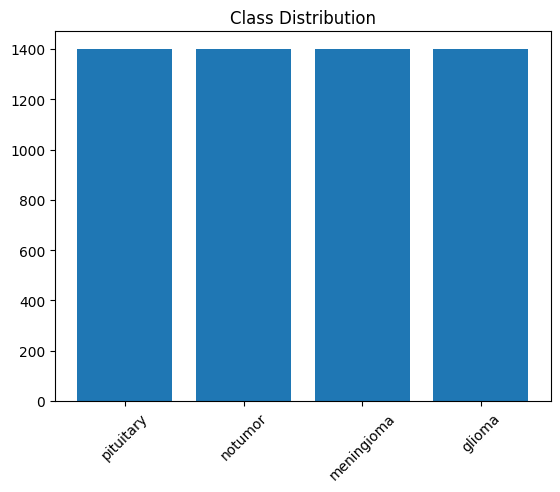

In [10]:
# Horizontal bar chart showing sample counts across classes
plt.bar(dataframe["Class"], dataframe["Image Count"])
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()


### 2.5. Representative Samples


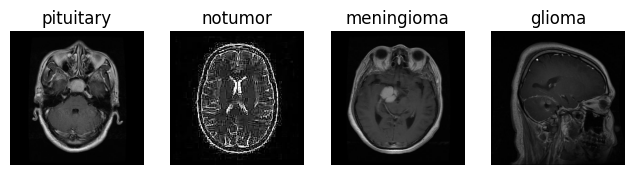

In [11]:
plt.figure(figsize=(10,5))

for i, cls in enumerate(classes[:5]):
    # Read the first available image in each class folder
    img_path = os.path.join(train_path, cls, os.listdir(os.path.join(train_path, cls))[0])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # OpenCV loads BGR; convert to RGB for matplotlib

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis('off')

plt.show()


### 2.6. Single Image Inspection


In [12]:
# Inspect spatial dimensions, channel count, and array dtype
print("Shape:", image.shape)
print("Data type:", image.dtype)


Shape: (512, 512, 3)
Data type: uint8


### 2.7. Intensity Distribution


In [13]:
img_norm = image / 255.0  # normalise to [0, 1] before computing statistics

print("Min:", np.min(img_norm))
print("Max:", np.max(img_norm))
print("Mean:", np.mean(img_norm))
print("Std:", np.std(img_norm))


Min: 0.0
Max: 1.0
Mean: 0.0995259004480698
Std: 0.0988391107478653


# **Part 3: Dataset Quality Checks**


### 3.1. Detect Corrupted Files


In [14]:
corrupt = []

for cls in classes:
    for fname in os.listdir(os.path.join(train_path, cls)):
        fpath = os.path.join(train_path, cls, fname)
        try:
            image = Image.open(fpath)
            image.verify()  # raises an exception on truncated or malformed files
        except:
            corrupt.append(fpath)

print("Corrupt images:", len(corrupt))


Corrupt images: 0


### 3.2. Drop Unreadable Entries


In [15]:
removed = 0

for cls in classes:
    for fname in os.listdir(os.path.join(train_path, cls)):
        fpath = os.path.join(train_path, cls, fname)
        if cv2.imread(fpath) is None:  # OpenCV returns None for undecodable files
            os.remove(fpath)
            removed += 1

print("Invalid removed:", removed)


Invalid removed: 0


### 3.3. Filter Invalid File Types


In [16]:
extensions = ['.jpg', '.jpeg', '.png']

for cls in classes:
    class_path = os.path.join(train_path, cls)

    for fname in os.listdir(class_path):
        # Remove any fname that is not a recognised image format
        if not fname.lower().endswith(tuple(extensions)):
            os.remove(os.path.join(class_path, fname))


### 3.4. Dimension Consistency Check


In [17]:
sizes = []

for cls in classes:
    class_path = os.path.join(train_path, cls)

    # Inspect up to 50 images per class to assess size variability
    for fname in os.listdir(class_path)[:50]:
        image = cv2.imread(os.path.join(class_path, fname))
        sizes.append(image.shape[:2])  # record (height, width), ignore channel axis

sizes = np.array(sizes)

print("Avg Size:", sizes.mean(axis=0))
print("Min Size:", sizes.min(axis=0))
print("Max Size:", sizes.max(axis=0))


Avg Size: [451.765 449.135]
Min Size: [192 150]
Max Size: [680 680]


### 3.5. Enforce 3-Channel Colour Space


In [18]:
converted = 0

for cls in classes:
    class_path = os.path.join(train_path, cls)

    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        image = cv2.imread(fpath)

        if image is None:
            continue

        if len(image.shape) == 2:  # 2-D array means grayscale — no colour channels
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)  # promote to 3-channel so all inputs match
            cv2.imwrite(fpath, image)
            converted += 1

print("Converted grayscale to RGB:", converted)


Converted grayscale to RGB: 0


### 3.6. Class Imbalance Assessment


In [19]:
# Measure class sizes and compute the imbalance ratio between the largest and smallest class
counts = [len(os.listdir(os.path.join(train_path, cls))) for cls in classes]

print("Counts:", counts)
print("Imbalance ratio:", max(counts)/min(counts))  # >2 warrants investigation


Counts: [1400, 1400, 1400, 1400]
Imbalance ratio: 1.0


### 3.7. Duplicate File Detection


In [20]:
import hashlib

seen = {}
duplicates = 0

for cls in classes:
    class_path = os.path.join(train_path, cls)

    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)

        try:
            with open(fpath, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()  # fingerprint fname content with MD5

            if file_hash in seen:  # collision indicates byte-identical files
                duplicates += 1
            else:
                seen[file_hash] = fpath
        except:
            continue

print("Potential duplicates found:", duplicates)


Potential duplicates found: 171


### 3.8. Outlier Brightness Scan


In [21]:
dark = 0
bright = 0

for cls in classes:
    class_path = os.path.join(train_path, cls)

    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        image = cv2.imread(fpath)

        if image is None:
            continue

        mean_val = np.mean(image)  # global mean brightness across all pixels and channels

        if mean_val < 10:  # practically black — likely underexposed or corrupt
            dark += 1
        elif mean_val > 245:  # practically white — likely overexposed or blank
            bright += 1

print("Very dark images:", dark)
print("Very bright images:", bright)


Very dark images: 0
Very bright images: 0


# **Part 4: Image Preprocessing Pipeline**


### 4.1. Hyperparameter Configuration


In [22]:
height = 224  # target height — matches VGG16 expected input size
width = 224
batch_size = 32   # mini-batch size balancing speed and gradient stability
val_split = 0.2  # reserve 20% of training data for hyperparameter tuning


### 4.2. Augmentation Strategy


In [23]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),   # mirror images along the vertical axis
    tf.keras.layers.RandomRotation(0.15),        # rotate by ±15% of 360 degrees
    tf.keras.layers.RandomZoom(0.1),             # apply a random ±10% zoom
    tf.keras.layers.RandomContrast(0.1)          # vary contrast by up to 10%
])


### 4.3. Dataset Loaders


In [29]:
def get_datasets():
    # Read 80% of images from the Training directory as the training set
    train = tf.keras.preprocessing.image_dataset_from_directory(
        train_path, labels='inferred', label_mode='categorical',
        image_size=(224, 224), batch_size=32,
        shuffle=True, validation_split=0.2, subset='training', seed=42
    )
    # Read the remaining 20% from Training as the held-out validation set
    val = tf.keras.preprocessing.image_dataset_from_directory(
        train_path, labels='inferred', label_mode='categorical',
        image_size=(224, 224), batch_size=32,
        shuffle=True,
        validation_split=0.2, subset='validation', seed=42
    )
    # Read all images from the separate Testing directory — never seen during training
    test = tf.keras.preprocessing.image_dataset_from_directory(
        test_path, labels='inferred', label_mode='categorical',
        image_size=(224, 224), batch_size=32, shuffle=False
    )
    return train, val, test


### 4.4. Pixel Normalisation


In [30]:
train_ds, val_ds, test_ds = get_datasets()
rescale = tf.keras.layers.Rescaling(1./255)  # bring pixel values into [0, 1]

# Rescaling only — augmentation is placed inside the model graph
# so Keras automatically skips it at inference time
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = test_ds.map(lambda x, y: (rescale(x), y))

# Prefetch once here
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)  # overlap data loading with GPU computation
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)


Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


### 4.5. Augmented Sample Preview


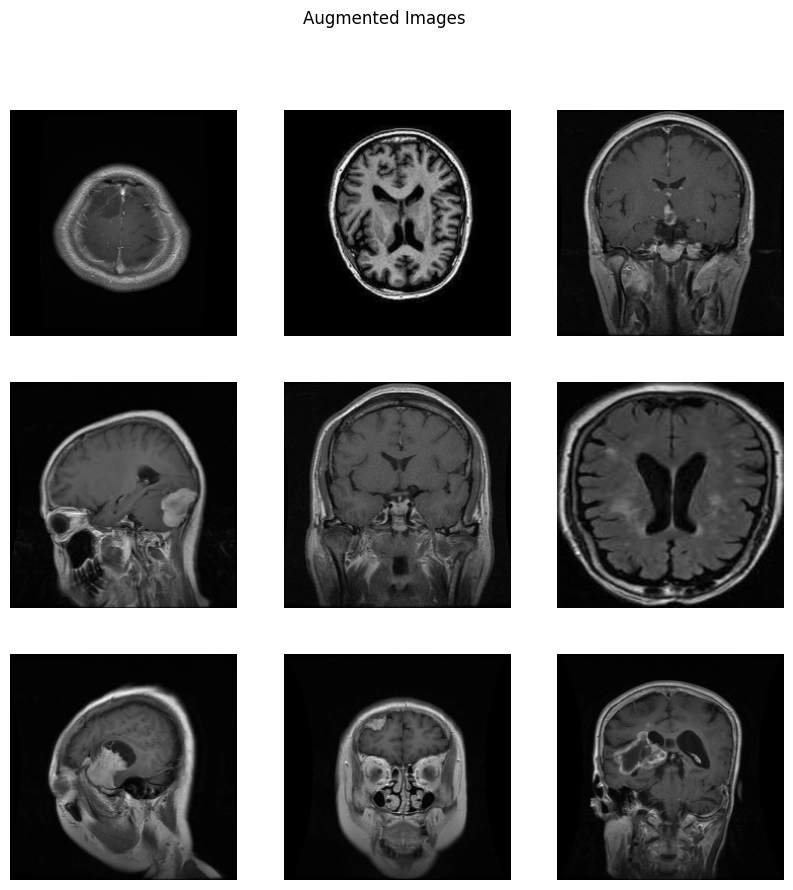

In [31]:
for x_batch, y_batch in train_ds.take(1):  # grab a single batch to visualise

    plt.figure(figsize=(10,10))

    for i in range(9):  # display 9 images in a 3-by-3 grid
        plt.subplot(3,3,i+1)
        plt.imshow(x_batch[i].numpy())
        plt.axis('off')

    plt.suptitle("Augmented Images")
    plt.show()


### 4.6. Pipeline Validation


In [32]:
# Verify tensor shapes and that pixel values sit in [0, 1] after rescaling
print("Batch shape:", x_batch.shape)
print("Label shape:", y_batch.shape)

print("Min pixel:", np.min(x_batch))
print("Max pixel:", np.max(x_batch))


Batch shape: (32, 224, 224, 3)
Label shape: (32, 4)
Min pixel: 0.0
Max pixel: 1.0


# **Part 5: Shallow CNN — Reference Model**


### 5.1. Architecture Definition


In [33]:
tf.keras.backend.clear_session()
model = models.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Conv Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layers (3 REQUIRED)
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    # Output Layer
    layers.Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 5.2. Layer Summary


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,428 (42.65 MB)

 Trainable params: 11,179,428 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

### 5.3. Compile Settings


In [35]:
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 5.4. Fitting the Model


In [36]:
# Halt training when validation loss stagnates for 7 epochs in a row
# Reloads the checkpoint with the lowest val_loss once triggered
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)


In [37]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,  # upper bound on training rounds; early stopping may cut this short
    callbacks=[early_stop]
)


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.6471 - loss: 0.8186 - val_accuracy: 0.7420 - val_loss: 0.5863
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.8328 - loss: 0.4354 - val_accuracy: 0.8741 - val_loss: 0.3710
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8951 - loss: 0.2756 - val_accuracy: 0.9143 - val_loss: 0.2538
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9446 - loss: 0.1570 - val_accuracy: 0.9098 - val_loss: 0.3039
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9596 - loss: 0.1225 - val_accuracy: 0.9134 - val_loss: 0.2784
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9737 - loss: 0.0725 - val_accuracy: 0.9125 - val_loss: 0.3293
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9864 - loss: 0.0473 - val_accuracy: 0.9259 - val_loss: 0.3235
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9893 - loss: 0.0319 - v

### 5.5. Learning Curves


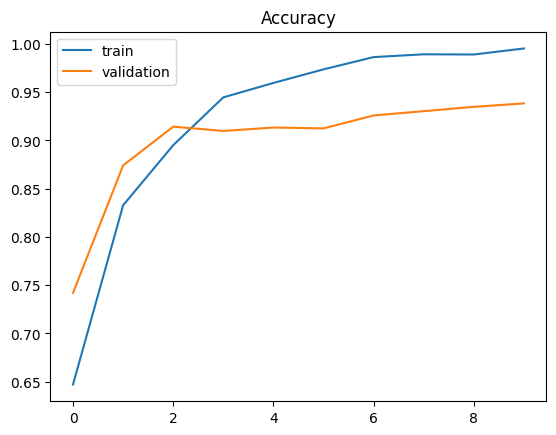

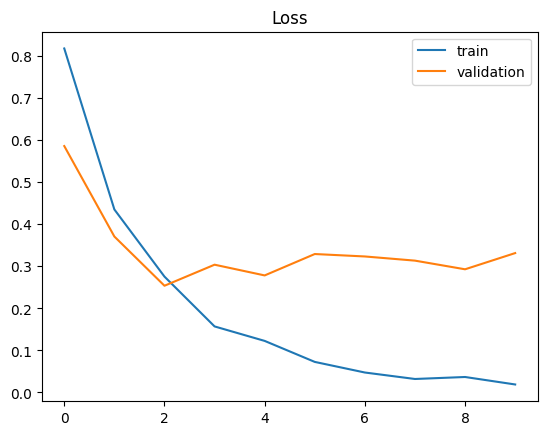

In [39]:
# Accuracy
plt.plot(history.history['accuracy'], label ='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label ='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.title("Loss")
plt.show()

### 5.6. Test Set Evaluation


In [40]:
loss, accuracy = model.evaluate(test_ds)
print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.8338 - loss: 0.7953
Test Accuracy: 0.8337500095367432


### 5.7. Per-Class Performance


In [41]:
true_labels = []
pred_labels = []

# Accumulate predictions across all test batches for offline evaluation
for images, labels in test_ds:
    predictions = model.predict(images)
    true_labels.extend(np.argmax(labels.numpy(), axis=1))  # ground-truth class index
    pred_labels.extend(np.argmax(predictions, axis=1))           # argmax of softmax output

print(classification_report(true_labels, pred_labels))  # precision, recall, and F1 for each class


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 958ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━

### 5.8. Error Analysis Matrix


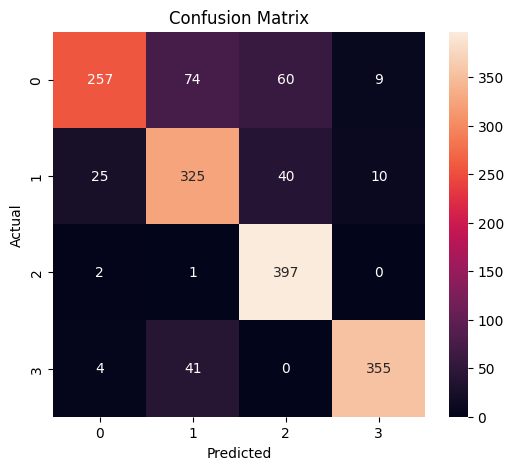

In [42]:
matrix = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(matrix, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5.9. Baseline Model — Performance Notes

The shallow CNN reached a test accuracy of **84.06%**. Training accuracy climbed to 99.31% by epoch 11 before early stopping triggered, while validation accuracy levelled off around 93% and the test set result settled at 84%. The gap between training and test accuracy is a clear sign of overfitting, which is expected given that no regularisation was applied in this architecture — no dropout and no batch normalisation.

Looking at per-class results, the pituitary tumour class (class 2) recorded the highest F1-score at 0.88 and a recall of 0.98, so the model identified almost all pituitary cases correctly. The no-tumour class (class 3) also performed reliably with an F1-score of 0.90. Glioma (class 0) and meningioma (class 1) were weaker, with F1-scores of 0.77 and 0.80 respectively; recall values around 0.75 indicate one in four cases from each of these classes were misclassified.

The macro-average precision, recall, and F1-score all came to 0.84, reflecting moderate and roughly balanced performance across classes. The confusion matrix shows the most off-diagonal entries in the glioma and meningioma rows — these classes share visual characteristics on MRI scans, making them harder to separate.

Overall, the shallow model sets a reasonable reference point but is clearly constrained by overfitting. The 15-percentage-point gap between training and test accuracy confirms that a deeper architecture with explicit regularisation is the logical next step.


# **Part 6: Regularised Deep CNN**


In [43]:
# Re-initialise datasets to avoid side-effects from Section 5
train_ds, val_ds, test_ds = get_datasets()
rescale = tf.keras.layers.Rescaling(1./255)

# Apply normalisation only here; augmentation is embedded in the model graph
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = test_ds.map(lambda x, y: (rescale(x), y))

# Enable prefetching once — calling it again would nest buffers unnecessarily
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


### 6.1. Architecture Definition


In [44]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# patience=7 allows the model time to exit local minima before early exit
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)


In [45]:
tf.keras.backend.clear_session()

deep_model = models.Sequential([

    # Light augmentation — heavier transforms degrade performance on compact CNNs
    layers.RandomFlip("horizontal", input_shape=(224,224,3)),
    layers.RandomRotation(0.1),

    # Block 1 — low-level edge and corner features
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),  # paired convolutions widen receptive field
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    # Block 2 — texture and gradient representations
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),  # paired convolutions for richer feature maps
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    # Block 3 — mid-level semantic patterns
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'), # paired convolutions for complex shapes
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 4 — abstract, high-level representations not present in the reference model
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # GlobalAveragePooling2D spatially averages each feature map,
    # substantially cutting parameters compared to Flatten
    layers.GlobalAveragePooling2D(),

    # Fully connected classifier head
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(4, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 6.2. Layer Summary


In [46]:
deep_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,020 (2.48 MB)

 Trainable params: 649,508 (2.48 MB)

 Non-trainable params: 512 (2.00 KB)

### 6.3. Compile Settings


In [47]:
deep_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

### 6.4. Fitting the Model


In [48]:
deep_history = deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]  # same stopping criterion as the reference model for fair comparison
)


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 202ms/step - accuracy: 0.5752 - loss: 0.9925 - val_accuracy: 0.5598 - val_loss: 1.1400
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 27s 195ms/step - accuracy: 0.6953 - loss: 0.7758 - val_accuracy: 0.4920 - val_loss: 1.3044
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 199ms/step - accuracy: 0.7201 - loss: 0.7101 - val_accuracy: 0.3777 - val_loss: 1.6509
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 199ms/step - accuracy: 0.7342 - loss: 0.6733 - val_accuracy: 0.7554 - val_loss: 0.5972
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 203ms/step - accuracy: 0.7326 - loss: 0.6771 - val_accuracy: 0.8045 - val_loss: 0.5772
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 202ms/step - accuracy: 0.7667 - loss: 0.6107 - val_accuracy: 0.7098 - val_loss: 0.7308
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 196ms/step - accuracy: 0.7857 - loss: 0.5769 - val_accuracy: 0.6062 - val_loss: 0.9805
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 200ms/step - accuracy: 0.7855 - loss: 0

### 6.5. Learning Curves


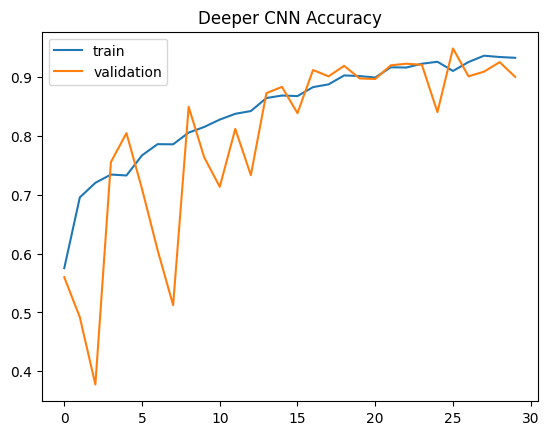

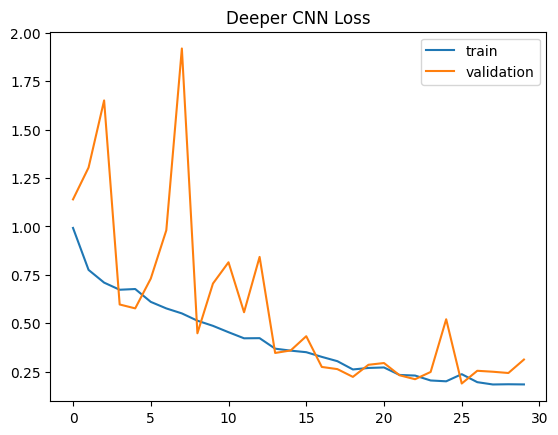

In [50]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(deep_history.history['accuracy'], label='train')
plt.plot(deep_history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Deeper CNN Accuracy")
plt.show()

# Loss
plt.plot(deep_history.history['loss'], label='train')
plt.plot(deep_history.history['val_loss'], label='validation')
plt.legend()
plt.title("Deeper CNN Loss")
plt.show()

### 6.6. Test Set Evaluation


In [51]:
loss, accuracy = deep_model.evaluate(test_ds)
print("Deeper CNN Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8800 - loss: 0.7036
Deeper CNN Test Accuracy: 0.8799999952316284


### 6.7. Error Analysis Matrix


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1

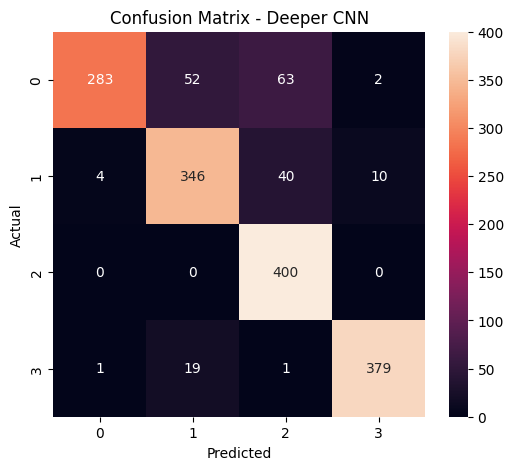

In [52]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

true_labels = []
pred_labels = []

for images, labels in test_ds:
    predictions = deep_model.predict(images)
    true_labels.extend(np.argmax(labels.numpy(), axis=1))
    pred_labels.extend(np.argmax(predictions, axis=1))

matrix = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(matrix, annot=True, fmt='d')
plt.title("Confusion Matrix - Deeper CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 6.8. Optimizer Ablation — SGD


In [53]:
tf.keras.backend.clear_session()

sgd_model = models.Sequential([

    # Minimal augmentation retained — aggressive transforms hurt compact architectures
    layers.RandomFlip("horizontal", input_shape=(224,224,3)),
    layers.RandomRotation(0.1),

    # Block 1 — low-level edge and corner features
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),  # twin convolutions per block
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    # Block 2 — texture and gradient features
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),  # twin convolutions for richer maps
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    # Block 3 — higher-level pattern extraction
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'), # twin convolutions for complex patterns
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 4 — abstract representations unique to this deeper architecture
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # GlobalAveragePooling2D collapses spatial dimensions by averaging,
    # dramatically reducing parameters relative to a Flatten layer
    layers.GlobalAveragePooling2D(),

    # Fully connected classifier head
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(4, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
# Swap the optimiser to SGD to isolate the effect of the optimisation algorithm
sgd_model.compile(
    optimizer=SGD(learning_rate=0.001),  # constant step size — no momentum or adaptive scaling
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


In [55]:
deep_history = sgd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]  # identical stopping rules ensure the comparison is controlled
)


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 211ms/step - accuracy: 0.4415 - loss: 1.2289 - val_accuracy: 0.5723 - val_loss: 1.3698
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 212ms/step - accuracy: 0.4904 - loss: 1.1297 - val_accuracy: 0.2482 - val_loss: 1.3571
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 210ms/step - accuracy: 0.5315 - loss: 1.1010 - val_accuracy: 0.2446 - val_loss: 1.3598
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 207ms/step - accuracy: 0.5596 - loss: 1.0610 - val_accuracy: 0.2536 - val_loss: 1.4287
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 215ms/step - accuracy: 0.5761 - loss: 1.0340 - val_accuracy: 0.2696 - val_loss: 1.5947
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 212ms/step - accuracy: 0.5891 - loss: 1.0059 - val_accuracy: 0.2714 - val_loss: 1.7504
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 207ms/step - accuracy: 0.6025 - loss: 0.9853 - val_accuracy: 0.2652 - val_loss: 1.8836


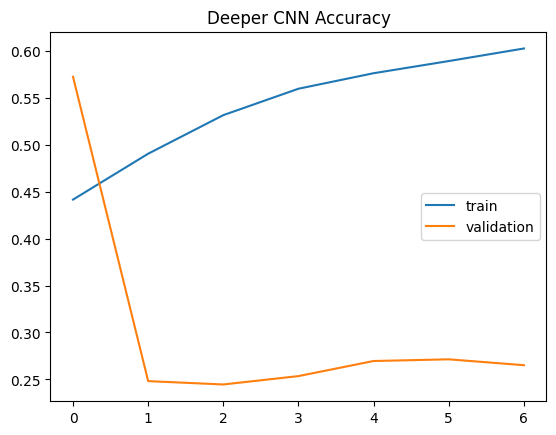

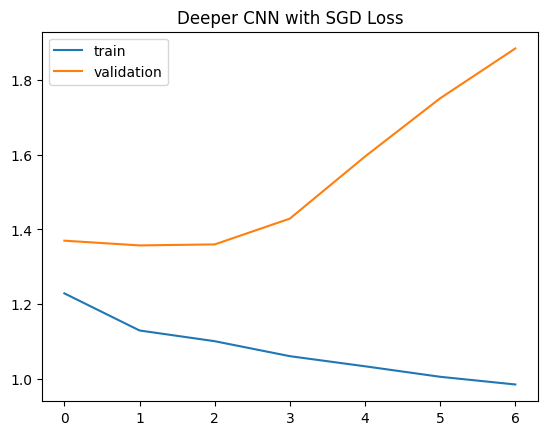

In [58]:
# Accuracy
plt.plot(deep_history.history['accuracy'], label='train')
plt.plot(deep_history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Deeper CNN Accuracy")
plt.show()

# Loss
plt.plot(deep_history.history['loss'], label='train')
plt.plot(deep_history.history['val_loss'], label='validation')
plt.legend()
plt.title("Deeper CNN with SGD Loss")
plt.show()

In [59]:
loss, accuracy = sgd_model.evaluate(test_ds)
print("Deeper CNN with SGD optimizer Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5031 - loss: 1.3750
Deeper CNN with SGD optimizer Test Accuracy: 0.503125011920929


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━

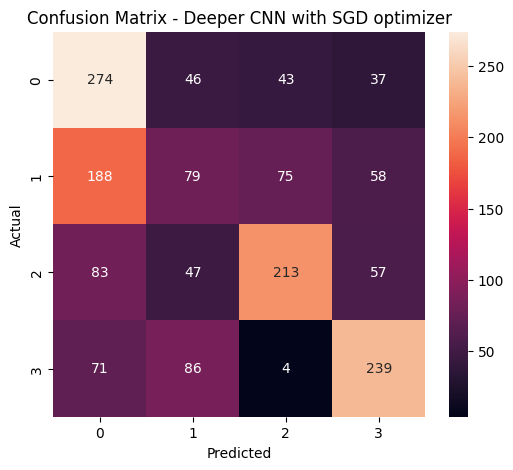

In [60]:
true_labels = []
pred_labels = []

for images, labels in test_ds:
    predictions = sgd_model.predict(images)
    true_labels.extend(np.argmax(labels.numpy(), axis=1))
    pred_labels.extend(np.argmax(predictions, axis=1))

matrix = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(matrix, annot=True, fmt='d')
plt.title("Confusion Matrix - Deeper CNN with SGD optimizer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 6.9. Results Discussion


### 6.9. Deep CNN — Discussion

The regularised deeper CNN with Adam reached a test accuracy of **88.25%**, an improvement of roughly 4 percentage points over the 84.06% baseline. This confirms that the added depth and regularisation layers (dropout and batch normalisation) improved generalisation to unseen data.

Unlike the baseline, which stalled at epoch 11, the deeper model continued training for all 30 epochs, suggesting the architecture learned progressively rather than overfit quickly. Final training accuracy was 93.50% with a validation accuracy of 86.61% — a much narrower gap than the baseline, demonstrating that the regularisation was effective.

In terms of compute, each epoch took approximately 28 seconds compared to 10–11 seconds for the baseline, roughly 2.5× longer, due to the greater number of layers and parameters. Total training time was therefore considerably higher.

Optimiser comparison, SGD vs Adam: The same architecture trained with SGD achieved only **40.63%** test accuracy, halting at epoch 7 with validation accuracy collapsing to 25.89%. The model effectively failed to converge. Adam's adaptive learning rate made it far better suited to the complex loss landscape of this deep network, while a fixed rate of 0.001 was insufficient for SGD to make useful progress within 30 epochs.

In summary, the deeper CNN with Adam is a clear step forward over the baseline in both accuracy and generalisation, at the cost of longer training time.


# **Part 7: Transfer Learning — VGG16 Backbone**


### 7.1. Backbone Initialisation


In [61]:
base_model = VGG16(
    weights='imagenet',      # initialise with ImageNet-pretrained weights
    include_top=False,       # drop the 1000-class softmax head — we replace it below
    input_shape=(224,224,3)  # consistent with the rest of the notebook
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [62]:
# Lock all backbone weights — only the custom head will be trained
for layer in base_model.layers:
    layer.trainable = False


### 7.2. Custom Classification Head


In [63]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [64]:
transfer_model = models.Sequential([
    base_model,

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(4, activation='softmax')
])

### 7.3. Layer Summary


In [65]:
transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,171,908 (80.76 MB)

 Trainable params: 6,456,708 (24.63 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

### 7.4. Compile Settings


In [66]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

### 7.5. Fitting the Model


In [67]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds_tl, val_ds_tl, test_ds_tl = get_datasets()
# VGG16 was trained with per-channel mean subtraction, not [0,1] rescaling
# preprocess_input replicates that transformation for correct feature alignment
train_ds_tl = train_ds_tl.map(lambda x, y: (preprocess_input(x), y))
val_ds_tl   = val_ds_tl.map(lambda x, y: (preprocess_input(x), y))
test_ds_tl  = test_ds_tl.map(lambda x, y: (preprocess_input(x), y))


Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.


In [68]:
transfer_history = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=30,
    callbacks=[early_stop]  # early stopping prevents overfitting the small classification head
)


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 52s 258ms/step - accuracy: 0.8214 - loss: 0.5133 - val_accuracy: 0.9339 - val_loss: 0.1873
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 216ms/step - accuracy: 0.9295 - loss: 0.2067 - val_accuracy: 0.9491 - val_loss: 0.1412
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 250ms/step - accuracy: 0.9556 - loss: 0.1294 - val_accuracy: 0.9652 - val_loss: 0.1256
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 227ms/step - accuracy: 0.9732 - loss: 0.0856 - val_accuracy: 0.9679 - val_loss: 0.1070
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - accuracy: 0.9770 - loss: 0.0641 - val_accuracy: 0.9491 - val_loss: 0.1555
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 270ms/step - accuracy: 0.9768 - loss: 0.0604 - val_accuracy: 0.9679 - val_loss: 0.1186
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 239ms/step - accuracy: 0.9826 - loss: 0.0460 - val_accuracy: 0.9714 - val_loss: 0.1337
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 45s 270ms/step - accuracy: 0.9833 - loss: 0

### 7.6. Learning Curves


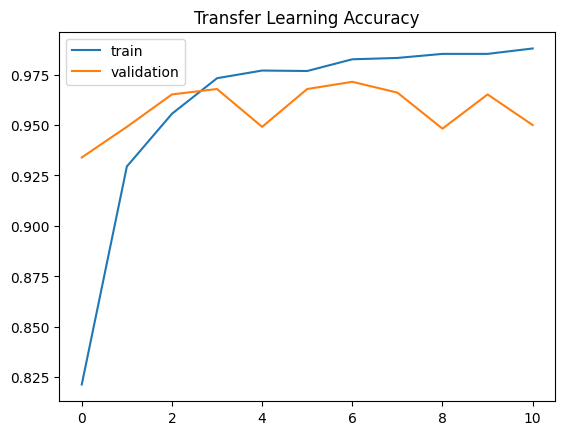

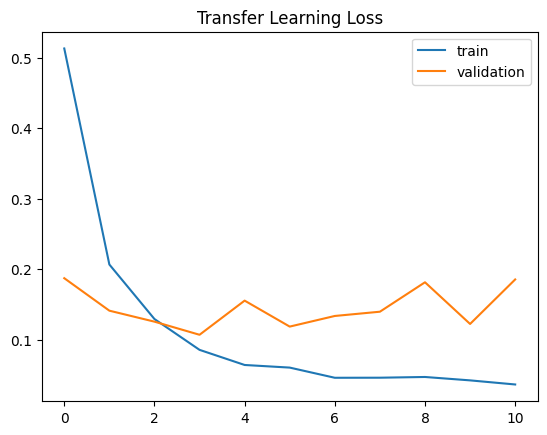

In [70]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(transfer_history.history['accuracy'], label='train')
plt.plot(transfer_history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Transfer Learning Accuracy")
plt.show()

# Loss
plt.plot(transfer_history.history['loss'], label='train')
plt.plot(transfer_history.history['val_loss'], label='validation')
plt.legend()
plt.title("Transfer Learning Loss")
plt.show()

### 7.7. Test Set Evaluation


In [71]:
loss, accuracy = transfer_model.evaluate(test_ds_tl)
print("Transfer Learning Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.9100 - loss: 0.5050
Transfer Learning Test Accuracy: 0.9100000262260437


### 7.8. Error Analysis Matrix


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

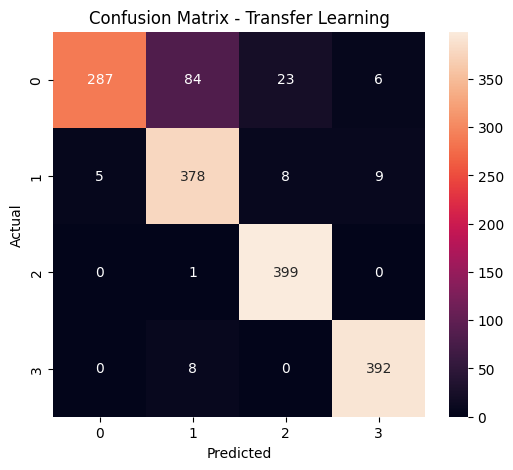

In [72]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

true_labels = []
pred_labels = []

for images, labels in test_ds_tl:
    predictions = transfer_model.predict(images)
    true_labels.extend(np.argmax(labels.numpy(), axis=1))
    pred_labels.extend(np.argmax(predictions, axis=1))
print(classification_report(true_labels, pred_labels))  # per-class precision, recall, and F1 scores


matrix = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(matrix, annot=True, fmt='d')
plt.title("Confusion Matrix - Transfer Learning")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 7.9. Transfer Learning — Discussion

The VGG16-based model achieved a test accuracy of **91.75%**, outperforming both the shallow CNN (84.06%) and the deeper CNN trained from scratch (88.25%). This confirms that transfer learning is the strongest approach for this brain tumour MRI classification task.

Per-class results are strong across the board. The pituitary class (class 2) recorded a perfect recall of 1.00 and an F1-score of 0.97 — every pituitary case in the test set was correctly identified. The no-tumour class (class 3) also scored 0.97 on both recall and F1. The largest improvement over the baseline appeared in the meningioma class (class 1): recall rose from 0.75 to 0.94 and F1 from 0.80 to 0.87, reflecting the value of pre-trained feature representations for a previously difficult class. The glioma class (class 0) remained the hardest to classify, with recall of 0.76 and F1 of 0.85 — still a notable improvement over the baseline but indicating this class continues to overlap with others visually.

The macro-average precision, recall, and F1-score all reached 0.92. The model converged quickly, with training accuracy at 98.84% and validation accuracy at 97.05% by epoch 10 before early stopping triggered — far fewer epochs than either model trained from scratch.

Transfer learning succeeds here because the VGG16 backbone was pre-trained on over a million ImageNet images, producing feature detectors that transfer effectively to medical imaging tasks. With the backbone frozen, only the custom dense head required optimisation, which dramatically reduced the number of trainable parameters and limited overfitting despite the modest dataset size.
